In [3]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == "rm_loss"]
dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
dfp = dfp.reindex(["identity", "actmat", "regmean"])
dfp.style.format("{:.2e}")

model,Olmo-3-7b,ViT-B-16,ViT-B-32,ViT-L-14,t5-base,t5-large
method,,,,,,
identity,3.19e+04,2.25e+05,7.50e+04,5.54e+05,2.71e+06,1.63e+07
actmat,2.76e+04,5.18e+05,8.86e+04,1.06e+06,3.72e+06,2.29e+07
regmean,3.59e+03,5.58e+04,1.64e+04,1.29e+05,3.85e+05,5.87e+06


/tmp/ipykernel_1106424/516282837.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == "t5-large"]


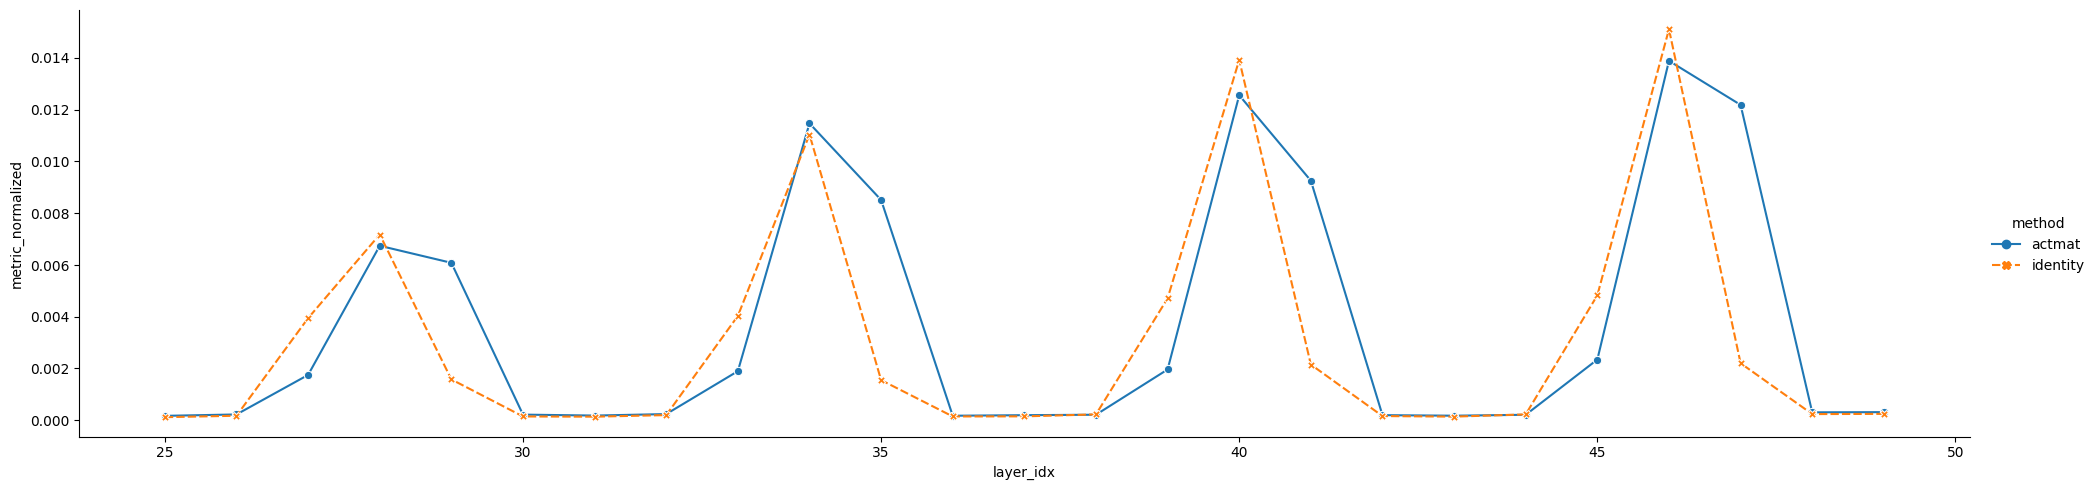

In [22]:
df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == "rm_loss"]
# dfp = dfp[df["model"] == "Olmo-3-7b"]
dfp = dfp[df["model"] == "t5-large"]
dfp["metric_normalized"] = dfp["metric"] / (dfp["Do"] * dfp["Di"])
dfp = dfp[dfp["method"].isin(["actmat", "identity"])]
dfp = dfp[(dfp["layer_idx"] >= 25) & (dfp["layer_idx"] < 50)]

g = sns.relplot(
    dfp,
    x="layer_idx",
    y="metric_normalized",
    hue="method",
    style="method",
    kind="line",
    markers=True,
    aspect=4,
)
# g.set(yscale="log")
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

In [2]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../artifacts/analysis/cov-estimate-error/cov-estimate-error.csv")
dfp = df.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
dfp = dfp.reindex(["identity", "actmat"])
dfp.style.format("{:.2e}")

model,Olmo-3-7b,ViT-B-16,ViT-B-32,ViT-L-14,t5-base,t5-large
method,,,,,,
identity,1.31e+01,8.12e+00,8.16e+00,1.59e+01,1.98e+01,3.52e+01
actmat,2.96e+01,1.82e+01,1.97e+01,4.04e+01,5.63e+01,9.04e+01


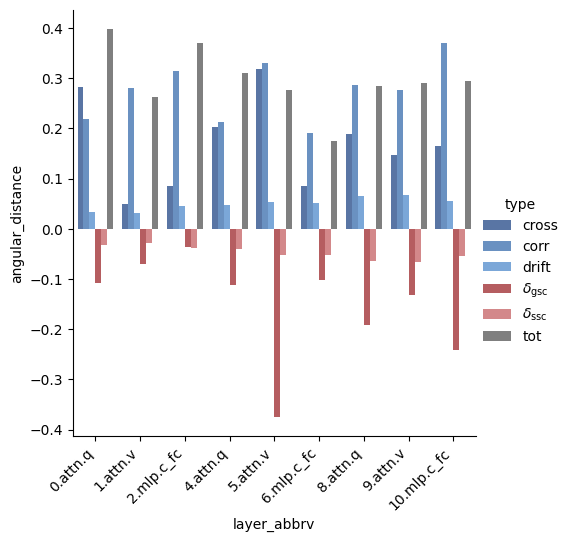

In [ ]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results-analysisv2-epochs1/{model}/group-main"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

# Filters:
df = df[df["dataset"] == "Cars"]
df = df[df["layer_idx"] % 8 == 0]

# Make layer abbrv
replace_strs = {
    "model.visual.transformer.resblocks.": "",
    ".weight": "",
}

df["layer_abbrv"] = df["layer_name"]
for old, new in replace_strs.items():
    df["layer_abbrv"] = df["layer_abbrv"].str.replace(old, new, regex=False)

hue_order = [
    "cross",
    "corr",
    "drift",
    r"$\delta_\text{gsc}$",
    r"$\delta_\text{ssc}$",
    "tot",
]

palette = {
    "cross": "#4C72B0",  # blues for the ε error terms
    "corr": "#5B8FCF",
    "drift": "#6BA6E8",
    r"$\delta_\text{gsc}$": "#C44E52",  # reds for the δ slack terms
    r"$\delta_\text{ssc}$": "#E07B7E",
    "tot": "#7F7F7F",  # grey for the total
}

g = sns.catplot(
    data=df,
    x="layer_abbrv",
    y="angular_distance",
    kind="bar",
    hue="type",
    hue_order=hue_order,
    palette=palette,
)
g.set_xticklabels(rotation=45, ha="right")